In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# For visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('final_all_multilingual_tweets(1).csv')

print("="*60)
print("DATASET INFO")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nLabel Distribution:")
print(df['labels'].value_counts())
print(f"\nPercentages:")
print(df['labels'].value_counts(normalize=True) * 100)

DATASET INFO
Shape: (2412, 2)

Label Distribution:
labels
Neutral     961
Positive    746
Negative    705
Name: count, dtype: int64

Percentages:
labels
Neutral     39.842454
Positive    30.928690
Negative    29.228856
Name: proportion, dtype: float64


In [3]:
def clean_tweet(text):
    """Clean and preprocess tweets"""
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (remove # but keep the word)
    text = re.sub(r'#', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def normalize_ghanaian_text(text):
    """Normalize common Ghanaian/Twi variations"""
    replacements = {
        r'\bgyimii?\b': 'gyimi',
        r'\bagyimi\b': 'gyimi',
        r'\bnkwasia\b': 'fool',
        r'\bkwasea\b': 'fool',
        r'\bpaa\b': 'very',
        r'\bɛyɛ\b': 'eye',
        r'\bɔ\b': 'o',
    }
    
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    return text

print(" Cleaning functions defined")

 Cleaning functions defined


In [4]:
# Apply cleaning
print("Cleaning tweets...")
df['cleaned_tweet'] = df['tweets'].apply(clean_tweet)
df['cleaned_tweet'] = df['cleaned_tweet'].apply(normalize_ghanaian_text)

# Remove empty tweets
df = df[df['cleaned_tweet'].str.len() > 0].reset_index(drop=True)
print(f"After cleaning: {len(df)} tweets remain")

# Show example
print("\n" + "="*60)
print("CLEANING EXAMPLE")
print("="*60)
print(f"Original: {df['tweets'].iloc[0]}")
print(f"Cleaned:  {df['cleaned_tweet'].iloc[0]}")

Cleaning tweets...
After cleaning: 2412 tweets remain

CLEANING EXAMPLE
Original: wode wo kwasea come here again
Cleaned:  wode wo fool come here again


In [5]:
# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['labels'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

# Train-test split
X = df['cleaned_tweet'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest distribution:")
print(pd.Series(y_test).value_counts())

Label Mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Training set size: 1929
Test set size: 483

Training distribution:
1    768
2    597
0    564
Name: count, dtype: int64

Test distribution:
1    193
2    149
0    141
Name: count, dtype: int64


In [6]:
print("\n" + "="*60)
print("TF-IDF VECTORIZATION")
print("="*60)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF features created: {X_train_tfidf.shape[1]}")


TF-IDF VECTORIZATION
TF-IDF features created: 5000


In [7]:
print("\n" + "="*60)
print("MODEL 1: NAIVE BAYES + TF-IDF")
print("="*60)

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, average='weighted')
nb_recall = recall_score(y_test, nb_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')

print(f"\n Naive Bayes Results:")
print(f"   Accuracy:  {nb_accuracy:.4f}")
print(f"   Precision: {nb_precision:.4f}")
print(f"   Recall:    {nb_recall:.4f}")
print(f"   F1-Score:  {nb_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, nb_pred, target_names=label_encoder.classes_))


MODEL 1: NAIVE BAYES + TF-IDF

 Naive Bayes Results:
   Accuracy:  0.6190
   Precision: 0.6505
   Recall:    0.6190
   F1-Score:  0.6150

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.44      0.51       141
     Neutral       0.55      0.79      0.65       193
    Positive       0.83      0.57      0.67       149

    accuracy                           0.62       483
   macro avg       0.66      0.60      0.61       483
weighted avg       0.65      0.62      0.61       483



In [8]:
print("\n" + "="*60)
print("MODEL 2: LOGISTIC REGRESSION + TF-IDF")
print("="*60)

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print(f"\n Logistic Regression Results:")
print(f"   Accuracy:  {lr_accuracy:.4f}")
print(f"   Precision: {lr_precision:.4f}")
print(f"   Recall:    {lr_recall:.4f}")
print(f"   F1-Score:  {lr_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, lr_pred, target_names=label_encoder.classes_))


MODEL 2: LOGISTIC REGRESSION + TF-IDF

 Logistic Regression Results:
   Accuracy:  0.6273
   Precision: 0.6373
   Recall:    0.6273
   F1-Score:  0.6297

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.62      0.59       141
     Neutral       0.59      0.63      0.61       193
    Positive       0.76      0.63      0.69       149

    accuracy                           0.63       483
   macro avg       0.64      0.63      0.63       483
weighted avg       0.64      0.63      0.63       483



In [9]:
print("\n" + "="*60)
print("MODEL 3: SVM + TF-IDF")
print("="*60)

svm_model = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print(f"\n SVM Results:")
print(f"   Accuracy:  {svm_accuracy:.4f}")
print(f"   Precision: {svm_precision:.4f}")
print(f"   Recall:    {svm_recall:.4f}")
print(f"   F1-Score:  {svm_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_))


MODEL 3: SVM + TF-IDF

 SVM Results:
   Accuracy:  0.6190
   Precision: 0.6362
   Recall:    0.6190
   F1-Score:  0.6230

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.62      0.58       141
     Neutral       0.58      0.62      0.60       193
    Positive       0.80      0.62      0.70       149

    accuracy                           0.62       483
   macro avg       0.64      0.62      0.62       483
weighted avg       0.64      0.62      0.62       483



In [10]:
print("\n" + "="*70)
print("ENSEMBLE METHODS: SOFT VOTING & STACKING")
print("="*70)


# ============================================
# METHOD 1: SOFT VOTING CLASSIFIER
# ============================================
print("\n" + "="*60)
print("METHOD 1: SOFT VOTING CLASSIFIER")
print("="*60)

# Soft Voting averages the probabilities from all three base models
# Each model outputs: P(Negative), P(Neutral), P(Positive)
# Soft Voting averages these probabilities and picks the highest

voting_soft = VotingClassifier(
    estimators=[
        ('naive_bayes', nb_model),      # Model 1: Naive Bayes
        ('logistic_regression', lr_model),  # Model 2: Logistic Regression
        ('svm', svm_model)              # Model 3: SVM
    ],
    voting='soft',      # 'soft' means average probabilities (not majority vote)
    weights=[1, 1, 1]   # Equal weights for all three models
)

# Train the soft voting ensemble
print("Training Soft Voting Classifier...")
voting_soft.fit(X_train_tfidf, y_train)

# Predict on test data
voting_soft_pred = voting_soft.predict(X_test_tfidf)

# Get probability scores (confidence levels)
voting_soft_proba = voting_soft.predict_proba(X_test_tfidf)

# Evaluate Soft Voting
voting_soft_accuracy = accuracy_score(y_test, voting_soft_pred)
voting_soft_precision = precision_score(y_test, voting_soft_pred, average='weighted')
voting_soft_recall = recall_score(y_test, voting_soft_pred, average='weighted')
voting_soft_f1 = f1_score(y_test, voting_soft_pred, average='weighted')

print(f"\n Soft Voting Results:")
print(f"   Accuracy:  {voting_soft_accuracy:.4f}")
print(f"   Precision: {voting_soft_precision:.4f}")
print(f"   Recall:    {voting_soft_recall:.4f}")
print(f"   F1-Score:  {voting_soft_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, voting_soft_pred, target_names=label_encoder.classes_))

# ============================================
# METHOD 2: STACKING CLASSIFIER
# ============================================
print("\n" + "="*60)
print("METHOD 2: STACKING CLASSIFIER")
print("="*60)

# Stacking uses a meta-model to learn which base model to trust
# Step 1: Base models (Naive Bayes, LR, SVM) make predictions
# Step 2: These predictions become features for the meta-model
# Step 3: Meta-model learns the best way to combine them

stacking = StackingClassifier(
    estimators=[
        ('naive_bayes', nb_model),           # Base model 1
        ('logistic_regression', lr_model),   # Base model 2
        ('svm', svm_model)                   # Base model 3
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000),  # Meta-model
    cv=5  # 5-fold cross-validation (prevents overfitting)
)

# Train the stacking ensemble
print("Training Stacking Classifier (this may take a few minutes)...")
stacking.fit(X_train_tfidf, y_train)

# Predict on test data
stacking_pred = stacking.predict(X_test_tfidf)

# Evaluate Stacking
stacking_accuracy = accuracy_score(y_test, stacking_pred)
stacking_precision = precision_score(y_test, stacking_pred, average='weighted')
stacking_recall = recall_score(y_test, stacking_pred, average='weighted')
stacking_f1 = f1_score(y_test, stacking_pred, average='weighted')

print(f"\n Stacking Results (Logistic Regression as meta-model):")
print(f"   Accuracy:  {stacking_accuracy:.4f}")
print(f"   Precision: {stacking_precision:.4f}")
print(f"   Recall:    {stacking_recall:.4f}")
print(f"   F1-Score:  {stacking_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, stacking_pred, target_names=label_encoder.classes_))


ENSEMBLE METHODS: SOFT VOTING & STACKING

METHOD 1: SOFT VOTING CLASSIFIER
Training Soft Voting Classifier...

 Soft Voting Results:
   Accuracy:  0.6356
   Precision: 0.6535
   Recall:    0.6356
   F1-Score:  0.6377

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.56      0.57       141
     Neutral       0.58      0.70      0.63       193
    Positive       0.81      0.62      0.70       149

    accuracy                           0.64       483
   macro avg       0.66      0.63      0.64       483
weighted avg       0.65      0.64      0.64       483


METHOD 2: STACKING CLASSIFIER
Training Stacking Classifier (this may take a few minutes)...

 Stacking Results (Logistic Regression as meta-model):
   Accuracy:  0.6460
   Precision: 0.6525
   Recall:    0.6460
   F1-Score:  0.6477

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.65      0.62       141
     Neut

In [11]:
print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON (3 Base + 2 Ensemble)")
print("="*70)

# Create comparison dataframe with all 5 models
all_models = [
    'Naive Bayes',
    'Logistic Regression', 
    'SVM',
    'Soft Voting (Ensemble)',
    'Stacking (Ensemble)'
]

all_accuracies = [
    nb_accuracy,
    lr_accuracy,
    svm_accuracy,
    voting_soft_accuracy,
    stacking_accuracy
]

all_precisions = [
    nb_precision,
    lr_precision,
    svm_precision,
    voting_soft_precision,
    stacking_precision
]

all_recalls = [
    nb_recall,
    lr_recall,
    svm_recall,
    voting_soft_recall,
    stacking_recall
]

all_f1_scores = [
    nb_f1,
    lr_f1,
    svm_f1,
    voting_soft_f1,
    stacking_f1
]

# Create DataFrame for display
comparison_df = pd.DataFrame({
    'Model': all_models,
    'Accuracy': [f'{x:.4f}' for x in all_accuracies],
    'Precision': [f'{x:.4f}' for x in all_precisions],
    'Recall': [f'{x:.4f}' for x in all_recalls],
    'F1-Score': [f'{x:.4f}' for x in all_f1_scores]
})

print(comparison_df.to_string(index=False))

# Find best model
best_idx = np.argmax(all_accuracies)
best_model_name = all_models[best_idx]
best_accuracy = all_accuracies[best_idx]

print(f"\n{'='*70}")
print(f" BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Check if ensemble methods improved over best base model
best_base_idx = np.argmax([nb_accuracy, lr_accuracy, svm_accuracy])
best_base_name = ['Naive Bayes', 'Logistic Regression', 'SVM'][best_base_idx]
best_base_accuracy = [nb_accuracy, lr_accuracy, svm_accuracy][best_base_idx]

print(f"\n Improvement Analysis:")
print(f"   Best Base Model: {best_base_name} ({best_base_accuracy:.4f})")
print(f"   Soft Voting:     {voting_soft_accuracy:.4f} (Δ = {voting_soft_accuracy - best_base_accuracy:+.4f})")
print(f"   Stacking:        {stacking_accuracy:.4f} (Δ = {stacking_accuracy - best_base_accuracy:+.4f})")

if voting_soft_accuracy > best_base_accuracy:
    print(f"    Soft Voting improved by {(voting_soft_accuracy - best_base_accuracy)*100:.2f}%")
if stacking_accuracy > best_base_accuracy:
    print(f"    Stacking improved by {(stacking_accuracy - best_base_accuracy)*100:.2f}%")


COMPLETE MODEL COMPARISON (3 Base + 2 Ensemble)
                 Model Accuracy Precision Recall F1-Score
           Naive Bayes   0.6190    0.6505 0.6190   0.6150
   Logistic Regression   0.6273    0.6373 0.6273   0.6297
                   SVM   0.6190    0.6362 0.6190   0.6230
Soft Voting (Ensemble)   0.6356    0.6535 0.6356   0.6377
   Stacking (Ensemble)   0.6460    0.6525 0.6460   0.6477

 BEST MODEL: Stacking (Ensemble)
   Accuracy: 0.6460 (64.60%)

 Improvement Analysis:
   Best Base Model: Logistic Regression (0.6273)
   Soft Voting:     0.6356 (Δ = +0.0083)
   Stacking:        0.6460 (Δ = +0.0186)
    Soft Voting improved by 0.83%
    Stacking improved by 1.86%


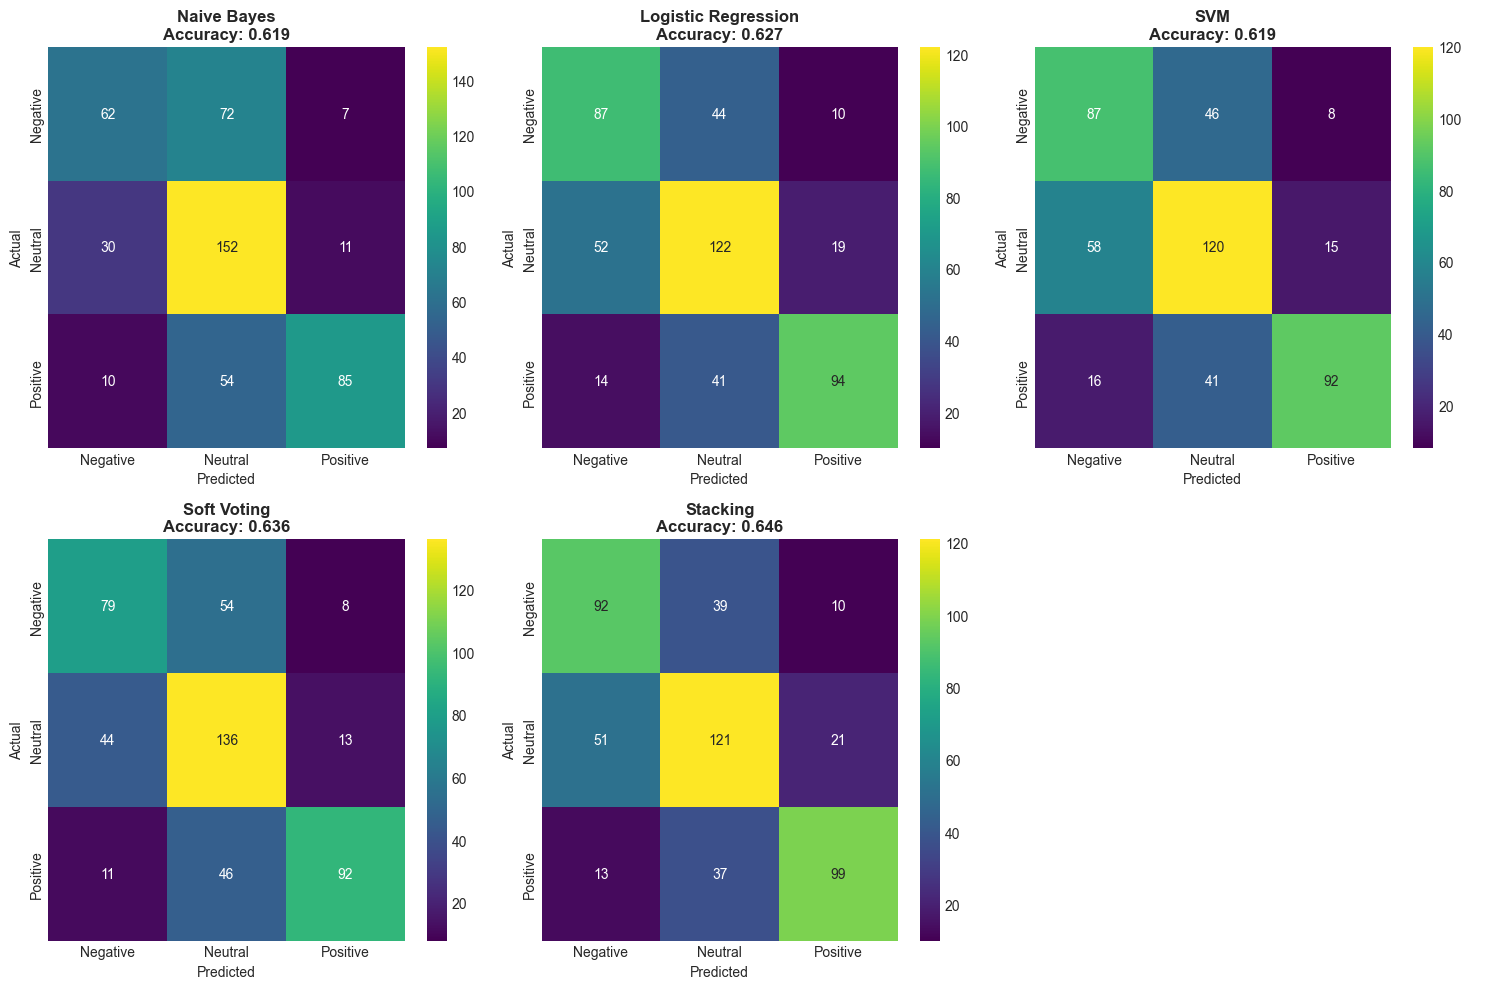

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# List of all models and their predictions
all_predictions = [
    (nb_pred, 'Naive Bayes', nb_accuracy),
    (lr_pred, 'Logistic Regression', lr_accuracy),
    (svm_pred, 'SVM', svm_accuracy),
    (voting_soft_pred, 'Soft Voting', voting_soft_accuracy),
    (stacking_pred, 'Stacking', stacking_accuracy)
]

# Plot confusion matrices (5 models in 2x3 grid, leaving bottom-right empty)
for idx, (preds, name, acc) in enumerate(all_predictions):
    row = idx // 3
    col = idx % 3
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axes[row, col],
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    axes[row, col].set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

# Hide the empty subplot (bottom-right)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

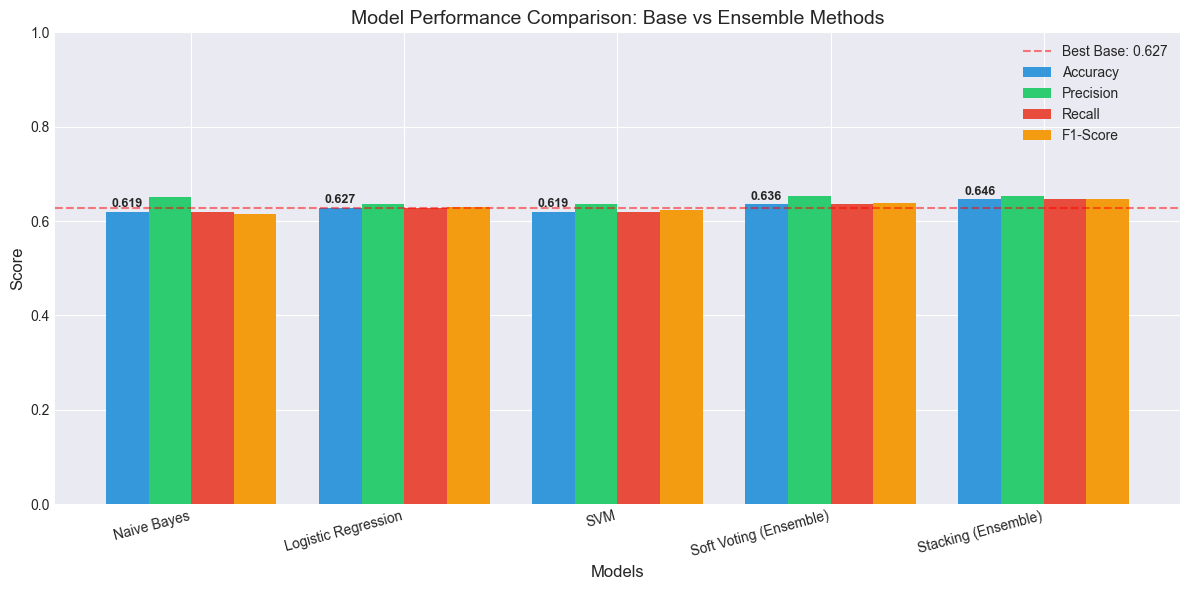

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_models))
width = 0.2

# Create bars for each metric
bars1 = ax.bar(x - width*1.5, all_accuracies, width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x - width/2, all_precisions, width, label='Precision', color='#2ecc71')
bars3 = ax.bar(x + width/2, all_recalls, width, label='Recall', color='#e74c3c')
bars4 = ax.bar(x + width*1.5, all_f1_scores, width, label='F1-Score', color='#f39c12')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Base vs Ensemble Methods', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(all_models, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=best_base_accuracy, color='red', linestyle='--', alpha=0.5, 
           label=f'Best Base: {best_base_accuracy:.3f}')

# Add value labels on accuracy bars
for i, (bar, acc) in enumerate(zip(bars1, all_accuracies)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()


CONFIDENCE INTERVALS (Normal Approximation)

 Based on 483 test samples, 95% Confidence Level:
----------------------------------------------------------------------
Model                  Accuracy   95% CI Lower 95% CI Upper Margin of Error
----------------------------------------------------------------------
Naive Bayes            0.6190     0.5757       0.6624       ±0.0433
Logistic Regression    0.6273     0.5842       0.6704       ±0.0431
SVM                    0.6190     0.5757       0.6624       ±0.0433
Soft Voting            0.6356     0.5927       0.6785       ±0.0429
Stacking               0.6460     0.6033       0.6886       ±0.0426


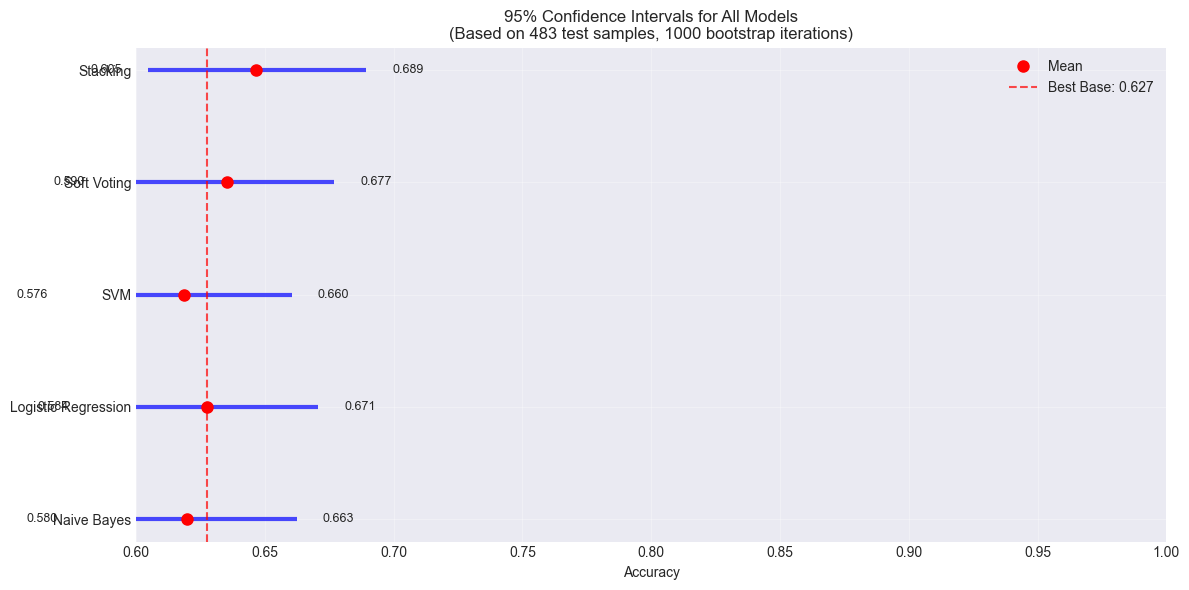

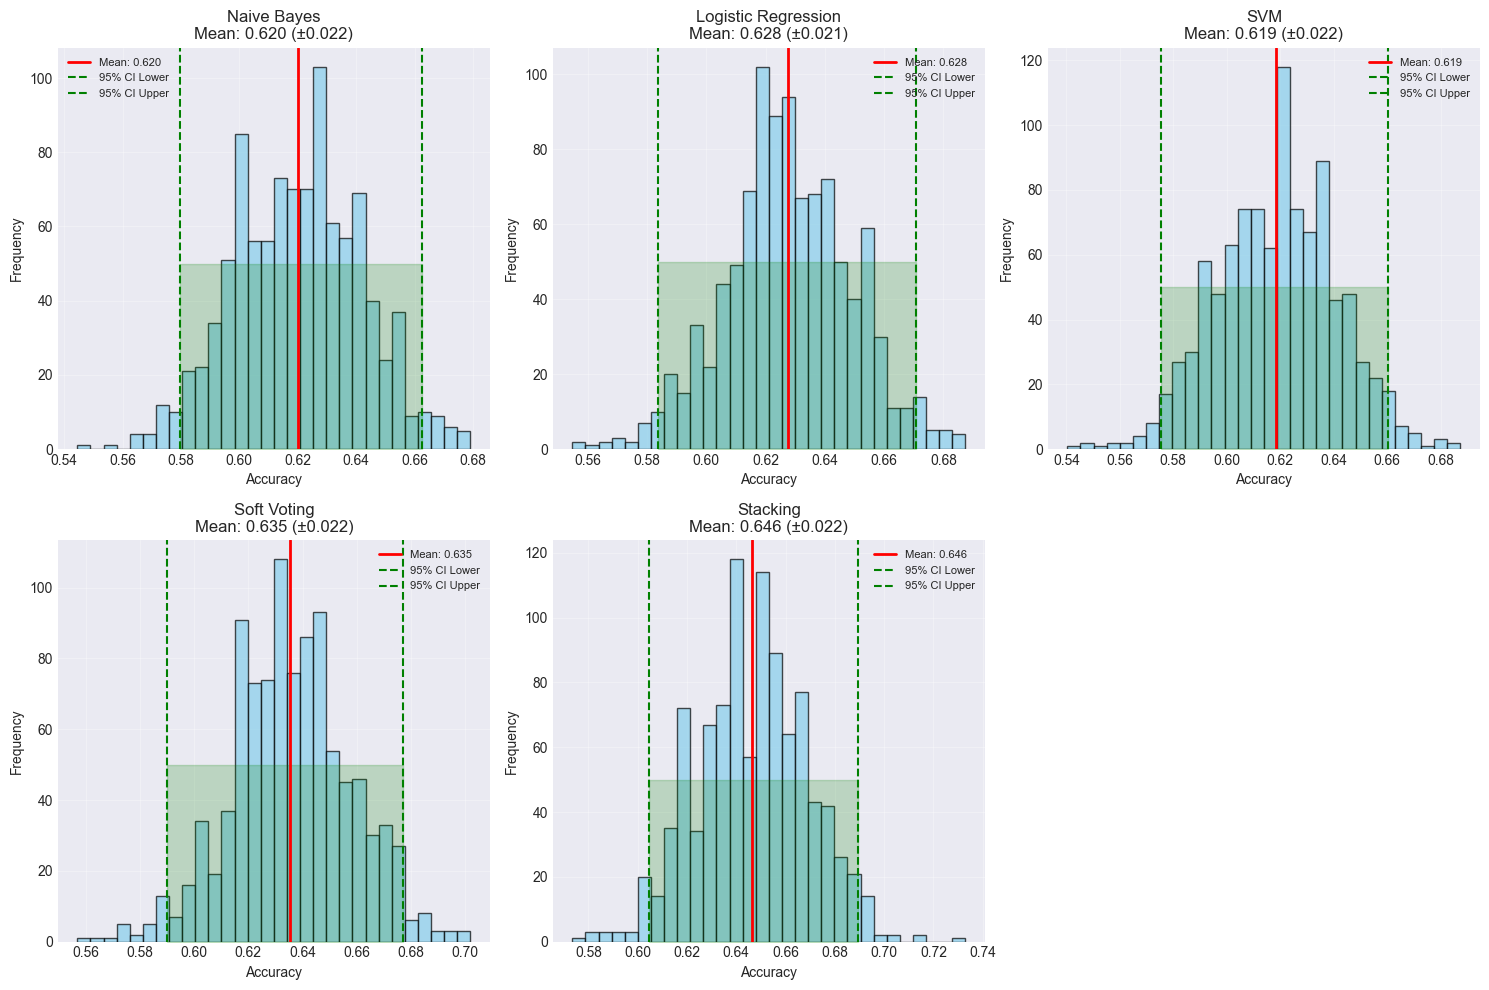

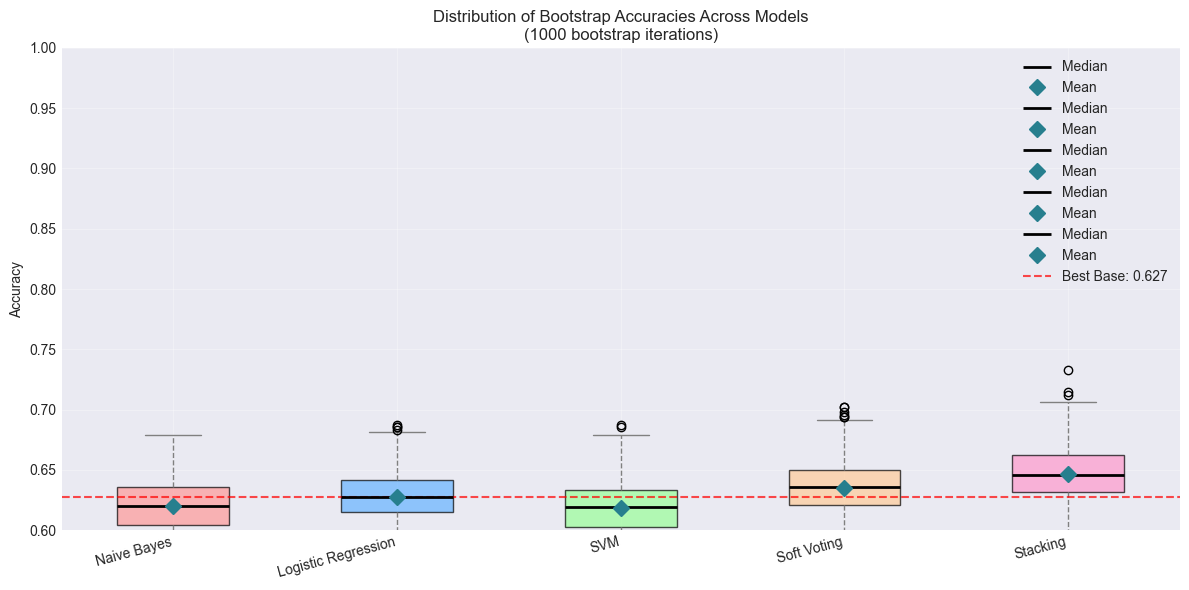

In [15]:
print("\n" + "="*70)
print("CONFIDENCE INTERVALS (Normal Approximation)")
print("="*70)

from math import sqrt
# This is what's MISSING from your notebook:

from sklearn.utils import resample

def bootstrap_confidence_interval(model, X_test, y_test, n_iterations=1000):
    """
    Calculate confidence intervals using bootstrap resampling
    More accurate than normal approximation for small samples
    """
    accuracies = []
    n_samples = len(y_test)
    
    for _ in range(n_iterations):
        # Resample test data with replacement
        indices = resample(range(n_samples), n_samples=n_samples, replace=True)
        X_boot = X_test[indices]
        y_boot = y_test[indices]
        
        # Predict and calculate accuracy
        y_pred = model.predict(X_boot)
        acc = accuracy_score(y_boot, y_pred)
        accuracies.append(acc)
    
    # Calculate confidence interval (percentile method)
    lower = np.percentile(accuracies, 2.5)
    upper = np.percentile(accuracies, 97.5)
    mean = np.mean(accuracies)
    std_error = np.std(accuracies)
    
    return {
        'model_name': model.__class__.__name__,
        'bootstrap_accuracies': accuracies,
        'mean_accuracy': mean,
        'lower_bound': lower,
        'upper_bound': upper,
        'std_error': std_error
    }

# Then create confidence_results:
confidence_results = []
for model, name in [(nb_model, 'Naive Bayes'), 
                     (lr_model, 'Logistic Regression'),
                     (svm_model, 'SVM'),
                     (voting_soft, 'Soft Voting'),
                     (stacking, 'Stacking')]:
    result = bootstrap_confidence_interval(model, X_test_tfidf, y_test)
    result['model_name'] = name
    confidence_results.append(result)

best_base_acc = max(nb_accuracy, lr_accuracy, svm_accuracy)


def calculate_confidence_interval_simple(accuracy, n_samples, confidence_level=0.95):
    """
    Calculate confidence interval using normal approximation
    
    Formula: CI = accuracy ± z * sqrt(accuracy * (1-accuracy) / n)
    """
    from scipy import stats
    
    z_score = stats.norm.ppf((1 + confidence_level) / 2)
    standard_error = sqrt(accuracy * (1 - accuracy) / n_samples)
    margin_of_error = z_score * standard_error
    
    lower = accuracy - margin_of_error
    upper = accuracy + margin_of_error
    
    return lower, upper, margin_of_error

# Get test set size
n_test = len(y_test)

# Calculate for each model
models_info = [
    ('Naive Bayes', nb_accuracy),
    ('Logistic Regression', lr_accuracy),
    ('SVM', svm_accuracy),
    ('Soft Voting', voting_soft_accuracy),
    ('Stacking', stacking_accuracy)
]

print(f"\n Based on {n_test} test samples, 95% Confidence Level:")
print("-" * 70)
print(f"{'Model':<22} {'Accuracy':<10} {'95% CI Lower':<12} {'95% CI Upper':<12} {'Margin of Error':<15}")
print("-" * 70)

for name, acc in models_info:
    lower, upper, moe = calculate_confidence_interval_simple(acc, n_test)
    print(f"{name:<22} {acc:.4f}     {lower:.4f}       {upper:.4f}       ±{moe:.4f}")


# ============================================
# Visualization 1: Confidence Interval Plot
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

models_names = [r['model_name'] for r in confidence_results]
means = [r['mean_accuracy'] for r in confidence_results]
lower_bounds = [r['lower_bound'] for r in confidence_results]
upper_bounds = [r['upper_bound'] for r in confidence_results]

# Create horizontal bar chart with error bars
y_pos = np.arange(len(models_names))

# Plot confidence intervals as horizontal lines
for i, (name, mean, lower, upper) in enumerate(zip(models_names, means, lower_bounds, upper_bounds)):
    # Plot the confidence interval line
    ax.hlines(y=i, xmin=lower, xmax=upper, color='blue', linewidth=3, alpha=0.7)
    # Plot the mean point
    ax.plot(mean, i, 'ro', markersize=8, label='Mean' if i == 0 else '')
    # Add text labels
    ax.text(lower - 0.01, i, f'{lower:.3f}', ha='right', va='center', fontsize=9)
    ax.text(upper + 0.01, i, f'{upper:.3f}', ha='left', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(models_names)
ax.set_xlabel('Accuracy')
ax.set_title(f'95% Confidence Intervals for All Models\n(Based on {len(y_test)} test samples, 1000 bootstrap iterations)', fontsize=12)
ax.set_xlim(0.6, 1.0)  # Adjust based on your accuracy range
ax.axvline(x=best_base_acc, color='red', linestyle='--', alpha=0.7, label=f'Best Base: {best_base_acc:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Distribution Plot (Histogram)
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, result in enumerate(confidence_results):
    ax = axes_flat[idx]
    
    # Plot histogram of bootstrap accuracies
    ax.hist(result['bootstrap_accuracies'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=result['mean_accuracy'], color='red', linestyle='-', linewidth=2, label=f'Mean: {result["mean_accuracy"]:.3f}')
    ax.axvline(x=result['lower_bound'], color='green', linestyle='--', linewidth=1.5, label=f'95% CI Lower')
    ax.axvline(x=result['upper_bound'], color='green', linestyle='--', linewidth=1.5, label=f'95% CI Upper')
    
    # Shade the confidence interval
    ax.fill_betweenx(y=[0, 50], x1=result['lower_bound'], x2=result['upper_bound'], 
                     color='green', alpha=0.2)
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{result["model_name"]}\nMean: {result["mean_accuracy"]:.3f} (±{result["std_error"]:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the last subplot (if we have 5 models, 2x3 grid has 6 spots)
axes_flat[5].axis('off')

plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Box Plot Comparison
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for box plot
box_data = [result['bootstrap_accuracies'] for result in confidence_results]
box_labels = [result['model_name'] for result in confidence_results]

# Create box plot
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)

# Customize colors
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize mean markers
plt.setp(bp['means'], color='red', marker='D', markersize=8, label='Mean')
plt.setp(bp['medians'], color='black', linewidth=2, label='Median')
plt.setp(bp['whiskers'], color='gray', linestyle='--')
plt.setp(bp['caps'], color='gray')

ax.set_ylabel('Accuracy')
ax.set_title('Distribution of Bootstrap Accuracies Across Models\n(1000 bootstrap iterations)', fontsize=12)
ax.set_ylim(0.6, 1.0)  # Adjust based on your accuracy range
ax.axhline(y=best_base_acc, color='red', linestyle='--', alpha=0.7, label=f'Best Base: {best_base_acc:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Custom Tweet Testing

def predict_with_all_models(text):
    """Predict sentiment using all 5 models (3 base + 2 ensemble)"""
    cleaned = clean_tweet(text)
    cleaned = normalize_ghanaian_text(cleaned)
    vec = tfidf.transform([cleaned])
    
    results = {
        'Tweet': text[:50] + '...' if len(text) > 50 else text,
    }
    
    # Base Models
    results['Naive Bayes'] = label_encoder.inverse_transform(nb_model.predict(vec))[0]
    results['Logistic Regression'] = label_encoder.inverse_transform(lr_model.predict(vec))[0]
    results['SVM'] = label_encoder.inverse_transform(svm_model.predict(vec))[0]
    
    # Ensemble Models
    results['Soft Voting'] = label_encoder.inverse_transform(voting_soft.predict(vec))[0]
    results['Stacking'] = label_encoder.inverse_transform(stacking.predict(vec))[0]
    
    # Get confidence scores for Soft Voting (optional)
    soft_voting_proba = voting_soft.predict_proba(vec)[0]
    results['Soft Voting Confidence'] = f"{np.max(soft_voting_proba):.2f}"
    
    return results

# Test examples (mix of positive, negative, neutral)
test_tweets = [
    "akwaaba welcome to the family! 🎉🎉🎉",
    "gyimie saa all cos of engagement its sad 💔",
    "wode maya is such a blessing, congratulations 🏆",
    "i dey watch the game, nothing special 😐",
    "wo kwasea come here again, you are foolish! 😡",
    "God bless you boss, you're doing great work! 🙏",
    "the weather today is okay, nothing exciting",
    "happy birthday bra andy 🎂🎊🎉"
]

print("\n" + "="*80)
print("CUSTOM TWEET TESTING: ALL 5 MODELS (3 Base + 2 Ensemble)")
print("="*80)

results_list = []
for tweet in test_tweets:
    results = predict_with_all_models(tweet)
    results_list.append(results)
    
    print(f"\n Tweet: {results['Tweet']}")
    print("-" * 65)
    
    # Show each model's prediction with emojis
    for model_name in ['Naive Bayes', 'Logistic Regression', 'SVM', 'Soft Voting', 'Stacking']:
        sentiment = results[model_name]
        if sentiment == 'Positive':
            emoji = '😊'
        elif sentiment == 'Negative':
            emoji = '😞'
        else:
            emoji = '😐'
        
        # Highlight if ensemble agrees with each other
        if model_name in ['Soft Voting', 'Stacking']:
            print(f"   {emoji}   {model_name:22s}: {sentiment}")
        else:
            print(f"   {emoji}    {model_name:22s}: {sentiment}")
    
    # Show Soft Voting confidence
    # if 'Soft Voting Confidence' in results:
    #     print(f"    Soft Voting Confidence: {results['Soft Voting Confidence']}")




CUSTOM TWEET TESTING: ALL 5 MODELS (3 Base + 2 Ensemble)

 Tweet: akwaaba welcome to the family! 🎉🎉🎉
-----------------------------------------------------------------
   😊    Naive Bayes           : Positive
   😊    Logistic Regression   : Positive
   😊    SVM                   : Positive
   😊   Soft Voting           : Positive
   😊   Stacking              : Positive

 Tweet: gyimie saa all cos of engagement its sad 💔
-----------------------------------------------------------------
   😞    Naive Bayes           : Negative
   😞    Logistic Regression   : Negative
   😞    SVM                   : Negative
   😞   Soft Voting           : Negative
   😞   Stacking              : Negative

 Tweet: wode maya is such a blessing, congratulations 🏆
-----------------------------------------------------------------
   😊    Naive Bayes           : Positive
   😊    Logistic Regression   : Positive
   😊    SVM                   : Positive
   😊   Soft Voting           : Positive
   😊   Stacking       

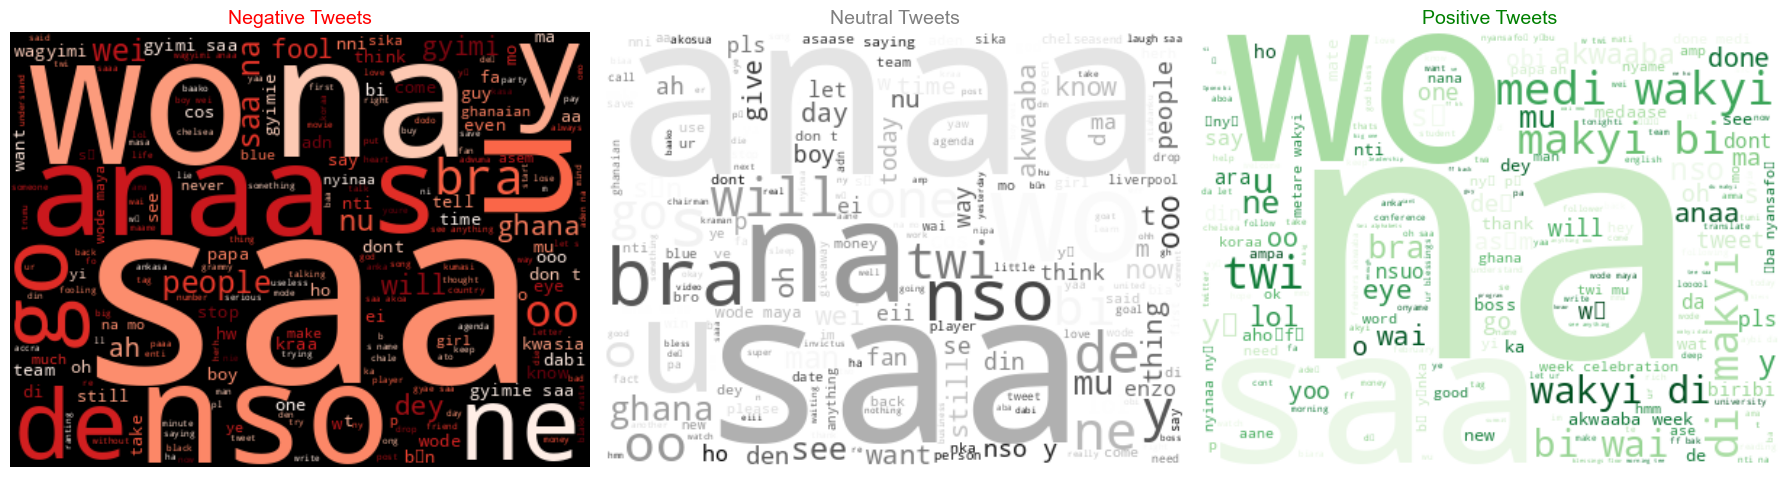

In [17]:
# Install wordcloud if needed
!pip install wordcloud -q

from wordcloud import WordCloud

# Get tweets for each sentiment
negative_tweets = ' '.join(df[df['labels'] == 'Negative']['cleaned_tweet'].astype(str))
neutral_tweets = ' '.join(df[df['labels'] == 'Neutral']['cleaned_tweet'].astype(str))
positive_tweets = ' '.join(df[df['labels'] == 'Positive']['cleaned_tweet'].astype(str))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Negative word cloud
wordcloud_neg = WordCloud(width=400, height=300, background_color='black', colormap='Reds').generate(negative_tweets)
axes[0].imshow(wordcloud_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Negative Tweets', color='red', fontsize=14)

# Neutral word cloud
wordcloud_neu = WordCloud(width=400, height=300, background_color='white', colormap='Greys').generate(neutral_tweets)
axes[1].imshow(wordcloud_neu, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Neutral Tweets', color='gray', fontsize=14)

# Positive word cloud
wordcloud_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(positive_tweets)
axes[2].imshow(wordcloud_pos, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('Positive Tweets', color='green', fontsize=14)

plt.tight_layout()
plt.show()

In [18]:
print("\n" + "="*70)
print("ENSEMBLE AGREEMENT ANALYSIS")
print("="*70)

# Check how often Soft Voting and Stacking agree
agreement_count = np.sum(voting_soft_pred == stacking_pred)
agreement_percentage = (agreement_count / len(voting_soft_pred)) * 100

print(f"\n Soft Voting vs Stacking Agreement:")
print(f"   Same prediction: {agreement_count} out of {len(voting_soft_pred)} tweets")
print(f"   Agreement rate: {agreement_percentage:.2f}%")

# Find where they disagree
disagreement_indices = np.where(voting_soft_pred != stacking_pred)[0]

if len(disagreement_indices) > 0:
    print(f"\n Where they disagree ({len(disagreement_indices)} cases):")
    print("-" * 60)
    
    for idx in disagreement_indices[:5]:  # Show first 5 disagreements
        print(f"\n   Tweet: {X_test[idx][:80]}...")
        print(f"   Soft Voting: {label_encoder.inverse_transform([voting_soft_pred[idx]])[0]}")
        print(f"   Stacking:    {label_encoder.inverse_transform([stacking_pred[idx]])[0]}")
        print(f"   Actual:      {label_encoder.inverse_transform([y_test[idx]])[0]}")
        
        # Show individual model predictions for this tweet
        nb_single = label_encoder.inverse_transform([nb_pred[idx]])[0]
        lr_single = label_encoder.inverse_transform([lr_pred[idx]])[0]
        svm_single = label_encoder.inverse_transform([svm_pred[idx]])[0]
        print(f"   Individual:  NB={nb_single}, LR={lr_single}, SVM={svm_single}")

# Calculate which ensemble is more accurate
soft_voting_correct = np.sum(voting_soft_pred == y_test)
stacking_correct = np.sum(stacking_pred == y_test)

print(f"\n Accuracy Breakdown:")
print(f"   Soft Voting correct: {soft_voting_correct}/{len(y_test)} ({soft_voting_correct/len(y_test)*100:.2f}%)")
print(f"   Stacking correct:    {stacking_correct}/{len(y_test)} ({stacking_correct/len(y_test)*100:.2f}%)")

# Cases where one ensemble is right and the other is wrong
soft_only_correct = np.sum((voting_soft_pred == y_test) & (stacking_pred != y_test))
stacking_only_correct = np.sum((stacking_pred == y_test) & (voting_soft_pred != y_test))

print(f"\n Unique Correct Predictions:")
print(f"   Only Soft Voting correct: {soft_only_correct} cases")
print(f"   Only Stacking correct:    {stacking_only_correct} cases")
print(f"   Both correct:             {agreement_count - np.sum((voting_soft_pred != y_test) & (stacking_pred != y_test))} cases")
print(f"   Both wrong:               {np.sum((voting_soft_pred != y_test) & (stacking_pred != y_test))} cases")


ENSEMBLE AGREEMENT ANALYSIS

 Soft Voting vs Stacking Agreement:
   Same prediction: 440 out of 483 tweets
   Agreement rate: 91.10%

 Where they disagree (43 cases):
------------------------------------------------------------

   Tweet: division amp division fo no na di agor saa no andy kerm bra b hw...
   Soft Voting: Neutral
   Stacking:    Negative
   Actual:      Negative
   Individual:  NB=Neutral, LR=Neutral, SVM=Neutral

   Tweet: akwaaba dance move by yemi and kanaga...
   Soft Voting: Neutral
   Stacking:    Positive
   Actual:      Neutral
   Individual:  NB=Neutral, LR=Positive, SVM=Positive

   Tweet: nffw kfb nd teach me teamtwi...
   Soft Voting: Neutral
   Stacking:    Positive
   Actual:      Positive
   Individual:  NB=Neutral, LR=Neutral, SVM=Positive

   Tweet: hmmm ewiem y ooecg nkurasifo no na mu ha mi ahoɔfɛ ewiem te sɛn...
   Soft Voting: Neutral
   Stacking:    Positive
   Actual:      Positive
   Individual:  NB=Positive, LR=Positive, SVM=Neutral

   Tweet: 

In [19]:
def predict_all_models(text):
    """Predict sentiment using all 5 models (3 base + 2 ensemble)"""
    cleaned = clean_tweet(text)
    cleaned = normalize_ghanaian_text(cleaned)
    vec = tfidf.transform([cleaned])
    
    results = {}
    
    # Base Model 1: Naive Bayes
    nb_pred = label_encoder.inverse_transform(nb_model.predict(vec))[0]
    nb_proba = nb_model.predict_proba(vec)[0]
    nb_confidence = np.max(nb_proba)
    results['Naive Bayes'] = {'sentiment': nb_pred, 'confidence': nb_confidence}
    
    # Base Model 2: Logistic Regression
    lr_pred = label_encoder.inverse_transform(lr_model.predict(vec))[0]
    lr_proba = lr_model.predict_proba(vec)[0]
    lr_confidence = np.max(lr_proba)
    results['Logistic Regression'] = {'sentiment': lr_pred, 'confidence': lr_confidence}
    
    # Base Model 3: SVM
    svm_pred = label_encoder.inverse_transform(svm_model.predict(vec))[0]
    svm_proba = svm_model.predict_proba(vec)[0]
    svm_confidence = np.max(svm_proba)
    results['SVM'] = {'sentiment': svm_pred, 'confidence': svm_confidence}
    
    # Ensemble Method 1: Soft Voting
    soft_pred = label_encoder.inverse_transform(voting_soft.predict(vec))[0]
    soft_proba = voting_soft.predict_proba(vec)[0]
    soft_confidence = np.max(soft_proba)
    results['Soft Voting'] = {'sentiment': soft_pred, 'confidence': soft_confidence}
    
    # Ensemble Method 2: Stacking
    stack_pred = label_encoder.inverse_transform(stacking.predict(vec))[0]
    stack_proba = stacking.predict_proba(vec)[0]
    stack_confidence = np.max(stack_proba)
    results['Stacking'] = {'sentiment': stack_pred, 'confidence': stack_confidence}
    
    return results

def interactive_test():
    """Interactive function to test custom tweets with all 5 models"""
    print("\n" + "="*70)
    print("INTERACTIVE TWEET SENTIMENT ANALYZER")
    print("   Models: Naive Bayes | Logistic Regression | SVM | Soft Voting | Stacking")
    print("="*70)
    print("\n Instructions:")
    print("   - Type any tweet in English, Twi, or Ghanaian Pidgin")
    print("   - Type 'quit' to exit")
    print("   - Type 'examples' to see sample tweets")
    print("="*70)
    
    emoji_map = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😞'}
    
    
    while True:
        user_input = input("\n Enter a tweet: ").strip()
        
        if user_input.lower() == 'quit':
            print("\n👋 Goodbye! Thanks for using the Sentiment Analyzer!")
            break
        
        if user_input.lower() == 'examples':
            print("\n Sample Tweets:")
            for key, tweet in sample_tweets.items():
                print(f"   {key}. {tweet}")
            print("\n   Type the number (1-5) to test a sample, or type your own tweet.")
            continue
        
        # Check if user entered a sample number
        if user_input in ['1', '2', '3', '4', '5']:
            tweet = sample_tweets[user_input]
            print(f"\n Testing sample: {tweet}")
        else:
            tweet = user_input
        
        if not tweet.strip():
            print("    Please enter a valid tweet!")
            continue
        
        # Get predictions from all models
        results = predict_all_models(tweet)
        
        # Display results with formatting
        print("\n" + "="*70)
        print(" PREDICTION RESULTS")
        print("="*70)
        
        # Separate base models and ensemble models
        print("\n BASE MODELS:")
        print("-" * 50)
        for model_name in ['Naive Bayes', 'Logistic Regression', 'SVM']:
            result = results[model_name]
            emoji = emoji_map.get(result['sentiment'], '❓')
            confidence_pct = result['confidence'] * 100
            print(f"   {emoji} {model_name:22s}: {result['sentiment']:8s} (confidence: {confidence_pct:.1f}%)")
        
        print("\n ENSEMBLE METHODS:")
        print("-" * 50)
        for model_name in ['Soft Voting', 'Stacking']:
            result = results[model_name]
            emoji = emoji_map.get(result['sentiment'], '❓')
            confidence_pct = result['confidence'] * 100
            # Highlight ensemble methods with stars
            print(f"   {emoji}  {model_name:20s}: {result['sentiment']:8s} (confidence: {confidence_pct:.1f}%)")
        
        # Check if ensembles agree
        if results['Soft Voting']['sentiment'] == results['Stacking']['sentiment']:
            print(f"\n    ENSEMBLES AGREE: {results['Soft Voting']['sentiment']}")
        else:
            print(f"\n    ENSEMBLES DISAGREE: Soft={results['Soft Voting']['sentiment']}, Stack={results['Stacking']['sentiment']}")
        
        # Show confidence distribution for the best ensemble
        best_ensemble = 'Soft Voting' if results['Soft Voting']['confidence'] > results['Stacking']['confidence'] else 'Stacking'
        print(f"\n    Highest confidence: {best_ensemble} ({results[best_ensemble]['confidence']*100:.1f}%)")
        
        print("\n" + "="*70)

# Run the interactive tester
interactive_test()


INTERACTIVE TWEET SENTIMENT ANALYZER
   Models: Naive Bayes | Logistic Regression | SVM | Soft Voting | Stacking

 Instructions:
   - Type any tweet in English, Twi, or Ghanaian Pidgin
   - Type 'quit' to exit
   - Type 'examples' to see sample tweets



 Enter a tweet:  But this guy is extremely stupid



 PREDICTION RESULTS

 BASE MODELS:
--------------------------------------------------
   😞 Naive Bayes           : Negative (confidence: 41.2%)
   😊 Logistic Regression   : Positive (confidence: 39.2%)
   😊 SVM                   : Positive (confidence: 49.3%)

 ENSEMBLE METHODS:
--------------------------------------------------
   😞  Soft Voting         : Negative (confidence: 37.6%)
   😞  Stacking            : Negative (confidence: 37.8%)

    ENSEMBLES AGREE: Negative

    Highest confidence: Stacking (37.8%)




 Enter a tweet:  why are you so lame?



 PREDICTION RESULTS

 BASE MODELS:
--------------------------------------------------
   😐 Naive Bayes           : Neutral  (confidence: 75.4%)
   😐 Logistic Regression   : Neutral  (confidence: 61.4%)
   😐 SVM                   : Neutral  (confidence: 63.0%)

 ENSEMBLE METHODS:
--------------------------------------------------
   😐  Soft Voting         : Neutral  (confidence: 66.6%)
   😐  Stacking            : Neutral  (confidence: 74.2%)

    ENSEMBLES AGREE: Neutral

    Highest confidence: Stacking (74.2%)




 Enter a tweet:  quit



👋 Goodbye! Thanks for using the Sentiment Analyzer!
